In [1]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from utils import *
from einops import rearrange

from matplotlib.colors import ListedColormap

with open(obs_labels_path, "rb") as f:
    data_dict = pickle.load(f)

setup_plot_style()

from scipy.stats import mode
from numpy.lib.stride_tricks import sliding_window_view

def rolling_mode_fast(labels, window_size):
    """Fast rolling mode using strided views."""
    # Pad to handle edges
    pad_width = window_size // 2
    padded = np.pad(labels, pad_width, mode='edge')
    
    # Create sliding windows and compute mode
    windows = sliding_window_view(padded, window_size)
    return mode(windows, axis=1, keepdims=False).mode

In [2]:
mouse_id_list = list(data_dict.keys())[: -1] # get rid of the familiar vs novel first
smooth_window = 59

mouse_pred_dict_full = {}
for idx, mouse_id in enumerate(mouse_id_list):
    pred_d_s_pd = data_dict[mouse_id]
    mouse_pred_dict = {}
    for day_idx in np.arange(1, 9):
        for session_idx in np.arange(1, 4):
            pred_d_s = pred_d_s_pd[(pred_d_s_pd["day_id"] == day_idx) & (pred_d_s_pd["session_id"] == session_idx)]
            if len(pred_d_s) == 0:
                print(f"No data for {mouse_id} day {day_idx} session {session_idx}")
                continue
            pred_smpl = label_to_categories(pred_d_s["prediction"].values)
            smoothed_pred_d_s_categories = rolling_mode_fast(pred_smpl, smooth_window)
            concat_pred = np.stack([pred_d_s["prediction"].values, pred_smpl, smoothed_pred_d_s_categories])
            mouse_pred_dict[f"d{day_idx}_s{session_idx}"] = concat_pred
    mouse_pred_dict_full[mouse_id] = mouse_pred_dict

In [3]:
def calculate_labels_stats(mouse_id_list: str, 
                           mouse_pred_dict_full: dict,
                           days: np.array = np.arange(1, 9),
                           sessions: np.array = np.arange(1, 4)) -> dict:

    transition_prob_session = {}
    bout_duration_session = {}
        
    for mice_id in mouse_id_list:
        transition_prob_mtx = np.zeros((len(days), len(sessions), 4, 4))
        bout_duration_session_dict = {}
        
        for day_idx in days:
            for session_idx in sessions:
                bout_duration = {}
                for key in categories_label.keys():
                    bout_duration[key] = []
                bout_duration_session_dict[f"d{day_idx}_s{session_idx}"] = bout_duration

        pred_d_s_dict = mouse_pred_dict_full[mice_id]
        for idx, pred_d_s in enumerate(pred_d_s_dict.values()):
            pred_smpl_smooth = pred_d_s[2, :]
            
            day_idx = idx // 3
            session_idx = idx % 3
            bout_duration_day = bout_duration_session_dict[f"d{day_idx + 1}_s{session_idx + 1}"]

            for i in range(len(pred_smpl_smooth) - 1):
                current_state = pred_smpl_smooth[i]
                next_state = pred_smpl_smooth[i + 1]
                transition_prob_mtx[day_idx, session_idx, current_state - 1, next_state - 1] += 1
            
            transition_prob_mtx[day_idx, session_idx] -= np.diag(np.diag(transition_prob_mtx[day_idx, session_idx]))
            transition_prob_mtx[day_idx, session_idx] += 1e-6
            transition_prob_mtx[day_idx, session_idx] /= np.sum(transition_prob_mtx[day_idx, session_idx], axis = 1, keepdims = True)
            count_state_lengths(pred_smpl_smooth, bout_duration_day)

        transition_prob_session[mice_id] = transition_prob_mtx
        bout_duration_session[mice_id] = bout_duration_session_dict
    
    return transition_prob_session, bout_duration_session

In [4]:
obs_id_list = [key for key, val in label_to_cond_dict.items() if val == "obs"]
xpo_id_list = [key for key, val in label_to_cond_dict.items() if val == "xpo"]

transition_prob_session_obs, bout_duration_session_obs = calculate_labels_stats(obs_id_list, mouse_pred_dict_full)
transition_prob_session_xpo, bout_duration_session_xpo = calculate_labels_stats(xpo_id_list, mouse_pred_dict_full)

In [5]:
all_transition_mtx_obs = np.stack([*transition_prob_session_obs.values()])
mean_transition_mtx_per_animal_obs = np.mean(all_transition_mtx_obs, axis = (1, 2))
mean_transition_mtx_obs = np.mean(mean_transition_mtx_per_animal_obs, axis = 0)

all_transition_mtx_xpo = np.stack([*transition_prob_session_xpo.values()])
mean_transition_mtx_per_animal_xpo = np.mean(all_transition_mtx_xpo, axis = (1, 2))
mean_transition_mtx_xpo = np.mean(mean_transition_mtx_per_animal_xpo, axis = 0)

mean_transition_mtx_obs.shape, mean_transition_mtx_xpo.shape

((4, 4), (4, 4))

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from dataclasses import dataclass
from typing import Literal

@dataclass
class DecoderResult:
    """Container for decoder results."""
    accuracy: float
    balanced_accuracy: float
    auc: float
    p_value: float
    null_distribution: np.ndarray
    predictions: np.ndarray
    probabilities: np.ndarray


def decode_groups(
    X: np.ndarray,
    y: np.ndarray,
    model: Literal["logistic", "lda"] = "logistic",
    n_permutations: int = 10000,
    random_state: int = 42,
) -> DecoderResult:
    """
    Decode binary group membership from proportion features using LOO-CV.
    
    Parameters
    ----------
    X : np.ndarray
        Feature matrix of shape (n_samples, n_features).
        For proportions: (14, 4) where 4 is number of behavioral states.
    y : np.ndarray
        Binary labels of shape (n_samples,). Values should be 0 or 1.
    model : str
        Classifier type: "logistic" or "lda".
    n_permutations : int
        Number of permutations for significance testing.
    random_state : int
        Random seed for reproducibility.
        
    Returns
    -------
    DecoderResult
        Dataclass containing accuracy metrics, p-value, and null distribution.
    """
    rng = np.random.default_rng(random_state)
    n_samples = len(y)
    
    # Run LOO-CV with true labels
    predictions, probabilities = _run_loo_cv(X, y, model)
    
    # Compute metrics
    accuracy = np.mean(predictions == y)
    balanced_acc = balanced_accuracy_score(y, predictions)
    auc = roc_auc_score(y, probabilities)
    
    # Permutation test
    null_balanced_accs = np.zeros(n_permutations)
    for i in range(n_permutations):
        y_perm = rng.permutation(y)
        perm_preds, _ = _run_loo_cv(X, y_perm, model)
        null_balanced_accs[i] = balanced_accuracy_score(y_perm, perm_preds)
    
    # One-tailed p-value
    p_value = (np.sum(null_balanced_accs >= balanced_acc) + 1) / (n_permutations + 1)
    
    return DecoderResult(
        accuracy=accuracy,
        balanced_accuracy=balanced_acc,
        auc=auc,
        p_value=p_value,
        null_distribution=null_balanced_accs,
        predictions=predictions,
        probabilities=probabilities,
    )


def _run_loo_cv(
    X: np.ndarray,
    y: np.ndarray,
    model: Literal["logistic", "lda"],
) -> tuple[np.ndarray, np.ndarray]:
    """
    Run leave-one-out cross-validation.
    
    Returns predictions and probability estimates.
    """
    loo = LeaveOneOut()
    predictions = np.zeros(len(y), dtype=int)
    probabilities = np.zeros(len(y))
    
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        
        # Standardize features (fit on train only)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Fit classifier
        if model == "logistic":
            clf = LogisticRegression(solver="lbfgs", max_iter=1000)
        else:  # lda
            clf = LinearDiscriminantAnalysis()
        
        clf.fit(X_train_scaled, y_train)
        
        predictions[test_idx] = clf.predict(X_test_scaled)
        probabilities[test_idx] = clf.predict_proba(X_test_scaled)[0, 1]
    
    return predictions, probabilities


def plot_results(result: DecoderResult, ax=None) -> None:
    """Plot null distribution with observed statistic."""
    import matplotlib.pyplot as plt
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    
    ax.hist(result.null_distribution, bins=50, density=True, 
            alpha=0.7, color="gray", label="Null distribution")
    ax.axvline(result.balanced_accuracy, color="red", linestyle="--", 
               linewidth=2, label=f"Observed = {result.balanced_accuracy:.3f}")
    ax.axvline(0.5, color="black", linestyle=":", alpha=0.5, label="Chance")
    
    ax.set_xlabel("Balanced Accuracy")
    ax.set_ylabel("Density")
    ax.set_title(f"Permutation Test (p = {result.p_value:.4f})")
    ax.legend()
    
    return ax

from dataclasses import dataclass
import numpy as np


@dataclass
class DayByDayResult:
    """Container for day-by-day decoder results."""
    n_days: int
    results: list[DecoderResult]
    balanced_accuracies: np.ndarray
    p_values: np.ndarray
    
    def summary(self) -> None:
        """Print summary table."""
        print(f"{'Day':<6}{'Bal. Acc':<12}{'AUC':<10}{'p-value':<12}{'Sig.':<6}")
        print("-" * 46)
        for i, r in enumerate(self.results):
            sig = "*" if r.p_value < 0.05 else ""
            print(f"{i:<6}{r.balanced_accuracy:<12.3f}{r.auc:<10.3f}{r.p_value:<12.4f}{sig:<6}")


def decode_by_day(
    X: np.ndarray,
    y: np.ndarray,
    n_permutations: int = 10000,
    model: str = "logistic",
    random_state: int = 42,
) -> DayByDayResult:
    """
    Run decoder separately for each day.
    
    Parameters
    ----------
    X : np.ndarray
        Feature matrix of shape (n_days, n_samples, n_features).
        For your case: (8, 14, 4).
    y : np.ndarray
        Binary labels of shape (n_samples,).
    n_permutations : int
        Number of permutations for significance testing.
    model : str
        Classifier type passed to decode_groups.
    random_state : int
        Random seed for reproducibility.
        
    Returns
    -------
    DayByDayResult
        Container with results for each day.
    """
    n_days = X.shape[0]
    results = []
    
    for day in range(n_days):
        X_day = X[day]  # (n_samples, n_features)
        result = decode_groups(
            X_day, y, 
            model=model, 
            n_permutations=n_permutations,
            random_state=random_state + day,  # different seed per day
        )
        results.append(result)
    
    return DayByDayResult(
        n_days=n_days,
        results=results,
        balanced_accuracies=np.array([r.balanced_accuracy for r in results]),
        p_values=np.array([r.p_value for r in results]),
    )


def plot_by_day(result: DayByDayResult, ax=None):
    """Plot balanced accuracy across days with significance markers."""
    import matplotlib.pyplot as plt
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    
    days = np.arange(result.n_days)
    
    ax.bar(days, result.balanced_accuracies, color='steelblue', alpha=0.7, edgecolor='k')
    ax.axhline(0.5, color='gray', linestyle='--', label='Chance')
    
    # Mark significant days
    for i, p in enumerate(result.p_values):
        if p < 0.05:
            ax.annotate('*', (i, result.balanced_accuracies[i] + 0.02), 
                        ha='center', fontsize=14, fontweight='bold')
    
    ax.set_xlabel('Day')
    ax.set_ylabel('Balanced Accuracy')
    ax.set_xticks(days)
    ax.set_ylim(0, 1)
    ax.set_title('Decoder Performance by Day')
    ax.legend()
    
    return ax

In [24]:
early_days = np.arange(0, 3)
late_days = np.arange(5, 8)

X_all_days = np.concatenate([all_transition_mtx_obs.mean(axis = 2), all_transition_mtx_xpo.mean(axis = 2)], axis = 0)

X_early = X_all_days[:, early_days].mean(axis = 1)
X_late = X_all_days[:, late_days].mean(axis = 1)

off_diag_mask = ~np.eye(X_early.shape[-1], dtype=bool)

X_early = X_early[:, off_diag_mask]
X_late = X_late[:, off_diag_mask]

y_labels = np.concatenate([np.ones(len(all_transition_mtx_obs)), np.zeros(len(all_transition_mtx_xpo))])
X_early.shape, X_late.shape, y_labels

((14, 12),
 (14, 12),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.]))

In [25]:
result_early = decode_groups(X_early, y_labels)
result_late = decode_groups(X_late, y_labels)

result_early.balanced_accuracy, result_late.balanced_accuracy

(0.7444444444444445, 0.48888888888888893)

In [38]:
X_all_days_features = rearrange(X_all_days[:, :, off_diag_mask], 'animals days features -> days animals features')

day_results = decode_by_day(X_all_days_features, y_labels)

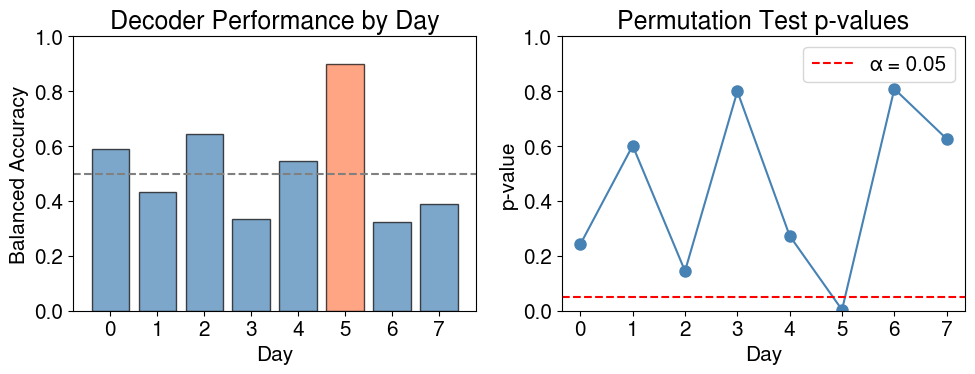

In [40]:
# Extract your results
balanced_accs = np.array([i.balanced_accuracy for i in day_results.results])
p_values = np.array([i.p_value for i in day_results.results])
aucs = np.array([i.auc for i in day_results.results])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Balanced accuracy by day
ax = axes[0]
colors = ['coral' if p < 0.05 else 'steelblue' for p in p_values]
ax.bar(range(8), balanced_accs, color=colors, alpha=0.7, edgecolor='k')
ax.axhline(0.5, color='gray', linestyle='--', label='Chance')
ax.set_xlabel('Day')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Decoder Performance by Day')
ax.set_xticks(range(8))
ax.set_ylim(0, 1)

# P-values by day
ax = axes[1]
ax.plot(range(8), p_values, 'o-', color='steelblue', markersize=8)
ax.axhline(0.05, color='red', linestyle='--', label='α = 0.05')
ax.set_xlabel('Day')
ax.set_ylabel('p-value')
ax.set_title('Permutation Test p-values')
ax.set_xticks(range(8))
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

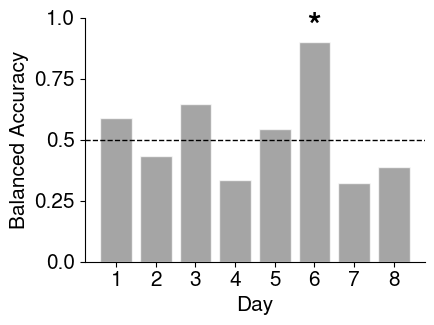

In [ ]:
# Extract your results
fontsize = 15
balanced_accs = np.array([i.balanced_accuracy for i in day_results.results])
p_values = np.array([i.p_value for i in day_results.results])
aucs = np.array([i.auc for i in day_results.results])

fig, ax = plt.subplots(figsize=(4.6, 3.5))
plt.bar(range(1, 9), balanced_accs, alpha = 0.7, edgecolor = "white", color = "gray")
for i, p in enumerate(p_values):
    if p < 0.05:
        ax.text(i + 1, balanced_accs[i] + 0.02, "*", ha = "center", fontsize = 25, fontweight = "bold")

ax.axhline(0.5, color='k', linestyle='--', label='Chance', lw = 1)
ax.set_xticks(range(1, 9), np.arange(1, 9), fontsize = fontsize)
ax.set_yticks(np.linspace(0, 1, 5), np.linspace(0, 1, 5), fontsize = fontsize)
ax.set_xlabel('Day', fontsize = fontsize)
ax.set_ylabel('Balanced Accuracy', fontsize = fontsize)
ax.set_ylim(0, 1)
plt.tight_layout()
sns.despine()

plt.savefig(os.path.join(fig_pub_path, "decoder_obs_xpo_by_day_accuracy.svg"), dpi = 300)